In [27]:
import warnings
warnings.filterwarnings('ignore')

In [28]:
import pandas as pd

df = pd.read_csv('export.csv', low_memory=False)

In [4]:
df.shape

(133574, 223)

In [29]:
# Remove empty columns
df.dropna(axis=1, how='all', inplace=True)

# Remove columns with only one unique value
for col in df.columns:
    if df[col].nunique() == 1:
        df.drop(col, axis=1, inplace=True)

print("Shape of the DataFrame after removing columns:")
display(df.shape)

Shape of the DataFrame after removing columns:


(133574, 123)

In [30]:
# Find and remove duplicate columns
df = df.T.drop_duplicates().T

print("Shape of the DataFrame after removing duplicate columns:")
display(df.shape)

Shape of the DataFrame after removing duplicate columns:


(133574, 121)

In [31]:
df_filtered_year = df[df['Year of diagnosis'] >= 2018].copy()
print("Shape of the DataFrame after filtering by year:")
display(df_filtered_year.shape)

Shape of the DataFrame after filtering by year:


(25622, 121)

In [32]:
df=df_filtered_year

In [33]:
display(df.shape)

(25622, 121)

In [34]:
# This is the list of columns with redauntdency or unnecessary to survival month detection
columns_to_drop = [
    #'Year of diagnosis',
    'Primary Site',
    'Histologic Type ICD-O-3',
    'Derived Summary Grade 2018 (2018+)',
    'Grade Clinical (2018+)',
    'Grade Pathological (2018+)',
    'ICD-O-3 Hist/behav, malignant',
    'ICCC site recode extended 3rd edition/IARC 2017',
    'Schema ID (2018+)',
    'AJCC ID (2018+)',
    'EOD Schema ID Recode (2010+)',
    'Summary stage 2000 (1998-2017)',
    'SEER historic stage A (1973-2015)',
    'Scope of reg lymph nd surg (1998-2002)',
    'RX Summ--Reg LN Examined (1998-2002)',
    'Surgery of oth reg/dis sites (1998-2002)',
    "Grade Recode (thru 2017)",
    'Site specific surgery (1973-1997 varying detail by year and site)',
    'RX Summ--Systemic/Sur Seq (2007+)',
    'EOD Primary Tumor Recode (2018+)',
    'EOD Regional Nodes Recode (2018+)',
    'EOD Mets Recode (2018+)',
    'Tumor Size Summary (2016+)',
    'Regional nodes examined (1988+)',
    'Regional nodes positive (1988+)',
    'Mets at DX-Distant LN (2016+)',
    'Mets at DX-Other (2016+)',
    'CS tumor size (2004-2015)',
    'CS extension (2004-2015)',
    'CS lymph nodes (2004-2015)',
    "AJCC stage 3rd edition (1988-2003)",
    'CS mets at dx (2004-2015)',
    'CS Tumor Size/Ext Eval (2004-2015)',
    'CS Reg Node Eval (2004-2015)',
    'CS Mets Eval (2004-2015)',
    'CS site-specific factor 1 (2004-2017 varying by schema)',
    'CS site-specific factor 2 (2004-2017 varying by schema)',
    'CS site-specific factor 3 (2004-2017 varying by schema)',
    'CS version input current (2004-2015)',
    'CS version input original (2004-2015)',
'Derived AJCC T, 7th ed (2010-2015)','Derived AJCC M, 7th ed (2010-2015)',
    'Derived AJCC N, 7th ed (2010-2015)',
    'Derived AJCC Stage Group, 7th ed (2010-2015)',
    'EOD 10 - extent (1988-2003)',
    'EOD 10 - nodes (1988-2003)',
    'EOD 10 - size (1988-2003)',
    'Coding system-EOD (1973-2003)',
    '2-Digit NS EOD part 1 (1973-1982)',
    '2-Digit SS EOD part 1 (1973-1982)',
    '2-Digit SS EOD part 2 (1973-1982)',
    'Expanded EOD(1) - CP53 (1973-1982)',
    'Expanded EOD(2) - CP54 (1973-1982)',
    'Expanded EOD(1,2) - CP53,54 (1973-1982)',
    'Expanded EOD(5) - CP57 (1973-1982)',
    'Expanded EOD(6) - CP58 (1973-1982)',
    'SEER cause-specific death classification',
    'SEER other cause of death classification',
    'Survival months flag',
    'COD to site rec KM',
    'COD to site recode ICD-O-3 2023 Revision',
    'COD to site recode ICD-O-3 2023 Revision Expanded (1999+)',
    'COD to site recode'
    'First malignant primary indicator',
    'Primary by international rules',
    'Record number recode',
    'Age recode with <1 year olds',
    'Year of follow-up recode',
    'Patient ID',
    "TNM 7/CS v0204+ Schema (thru 2017)",
    "Derived SEER Combined T Src (2016-2017)",
    "Derived SEER Combined N Src (2016-2017)",
    "Derived SEER Combined M Src (2016-2017)",
    "Derived SEER Cmb Stg Grp (2016-2017)",
    "CS site-specific factor 4 (2004-2017 varying by schema)",
    "CS site-specific factor 6 (2004-2017 varying by schema)",
    "TNM 7/CS v0204+ Schema (thru 2017)",
    "TNM 7/CS v0204+ Schema recode",
    'Site recode ICD-O-3 2023 Revision',
    'CS Schema - AJCC 6th Edition',
    'Primary Site - labeled'


]

df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')



In [35]:
df_cleaned.shape

(25622, 53)

In [36]:
df=df_cleaned

In [37]:
#missing value percentage
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})

# Display columns with missing values
display(missing_info[missing_info['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False))

,Missing Values,Missing Percentage
7th Edition Stage Group Recode (2016-2017),25622,100.000000
Derived SEER Combined T (2016-2017),25622,100.000000
Derived SEER Combined N (2016-2017),25622,100.000000
Derived SEER Combined M (2016-2017),25622,100.000000
"Derived AJCC Stage Group, 6th ed (2004-2015)",25622,100.000000
"Derived AJCC T, 6th ed (2004-2015)",25622,100.000000
"Derived AJCC N, 6th ed (2004-2015)",25622,100.000000
"Derived AJCC M, 6th ed (2004-2015)",25622,100.000000
TNM Edition Number (2016-2017),25622,100.000000
RX Summ--Scope Reg LN Sur (2003+),22814,89.040668


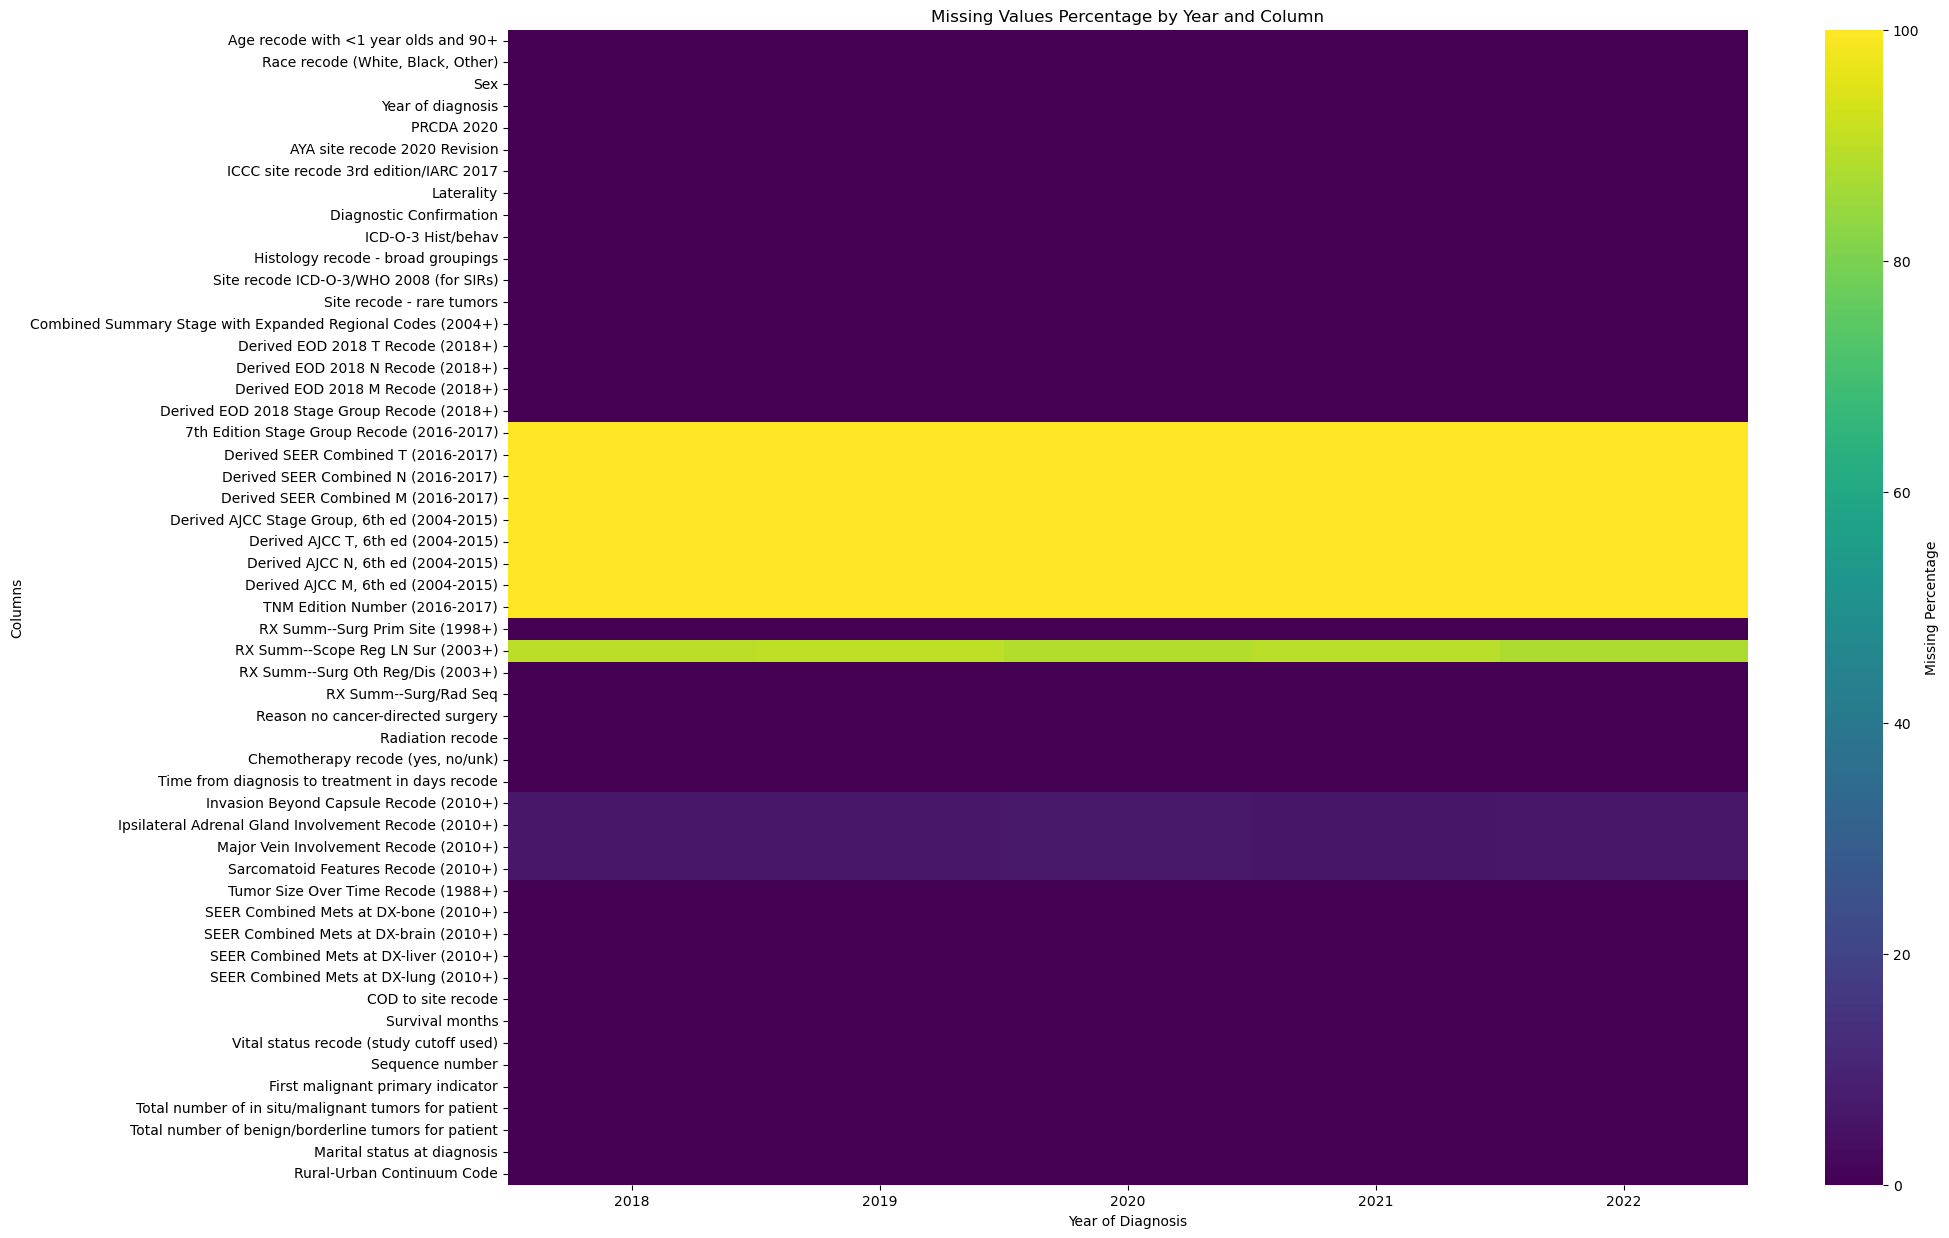

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Year of diagnosis' is treated as a year (assuming it's an integer or can be converted)
# If it's not in a suitable format, you might need to convert it first.
# For example, if it's a string, you might need:
# df['Year of diagnosis'] = pd.to_numeric(df['Year of diagnosis'], errors='coerce')

# Group by 'Year of diagnosis' and calculate the percentage of missing values per column per year
missing_by_year = df.groupby('Year of diagnosis').apply(lambda x: x.isnull().sum() / len(x) * 100).T

# Plot the heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(missing_by_year, cmap='viridis', cbar_kws={'label': 'Missing Percentage'})
plt.title('Missing Values Percentage by Year and Column')
plt.xlabel('Year of Diagnosis')
plt.ylabel('Columns')
plt.show()

In [39]:
df.shape

(25622, 53)

In [17]:
# TNM stage combine
t_columns = [
    'Derived EOD 2018 T Recode (2018+)',

    # 'Derived AJCC T, 6th ed (2004-2015)',
    # 'Derived SEER Combined T (2016-2017)',

]


n_columns = [
    'Derived EOD 2018 N Recode (2018+)',

    # 'Derived AJCC N, 6th ed (2004-2015)',
    # 'Derived SEER Combined N (2016-2017)',

]

m_columns = [
    'Derived EOD 2018 M Recode (2018+)',

    # 'Derived AJCC M, 6th ed (2004-2015)',
    # 'Derived SEER Combined M (2016-2017)',

]

stage_group_columns = [
    'Derived EOD 2018 Stage Group Recode (2018+)',

    # 'Derived AJCC Stage Group, 6th ed (2004-2015)',
    # '7th Edition Stage Group Recode (2016-2017)',

]

# Function to merge columns, taking the first non-null value
def merge_columns(row, columns):
    for col in columns:
        if pd.notna(row[col]):
            return row[col]
    return None

# Apply the merge function to create new combined columns
df['Combined_T_Stage'] = df.apply(lambda row: merge_columns(row, t_columns), axis=1)
df['Combined_N_Stage'] = df.apply(lambda row: merge_columns(row, n_columns), axis=1)
df['Combined_M_Stage'] = df.apply(lambda row: merge_columns(row, m_columns), axis=1)
df['Combined_Stage_Group'] = df.apply(lambda row: merge_columns(row, stage_group_columns), axis=1)

# Display the number of missing values in the new combined columns
print("Missing values in combined columns:")
print(df[['Combined_T_Stage', 'Combined_N_Stage', 'Combined_M_Stage', 'Combined_Stage_Group']].isnull().sum())

# Display the first few rows with the new combined columns
print("\nDataFrame with combined columns:")
display(df[['Combined_T_Stage', 'Combined_N_Stage', 'Combined_M_Stage', 'Combined_Stage_Group']].head())

Missing values in combined columns:
Combined_T_Stage        0
Combined_N_Stage        0
Combined_M_Stage        0
Combined_Stage_Group    0
dtype: int64

DataFrame with combined columns:


,Combined_T_Stage,Combined_N_Stage,Combined_M_Stage,Combined_Stage_Group
12,T1a,N0,M1,4
20,T3a,N0,M0,3
63,T1a,N0,M0,1
75,T1a,N0,M0,1
404,T1a,N0,M0,1


In [18]:
# List of original columns that were merged
original_t_columns = [
    'Derived EOD 2018 T Recode (2018+)',

    # 'Derived AJCC T, 6th ed (2004-2015)',
    # 'Derived SEER Combined T (2016-2017)',

]


original_n_columns = [
    'Derived EOD 2018 N Recode (2018+)',

    # 'Derived AJCC N, 6th ed (2004-2015)',
    # 'Derived SEER Combined N (2016-2017)',

]

original_m_columns = [
    'Derived EOD 2018 M Recode (2018+)',

    # 'Derived AJCC M, 6th ed (2004-2015)',
    # 'Derived SEER Combined M (2016-2017)',

]

original_stage_group_columns = [
    'Derived EOD 2018 Stage Group Recode (2018+)',

    # 'Derived AJCC Stage Group, 6th ed (2004-2015)',
    # '7th Edition Stage Group Recode (2016-2017)',
]

# Combine all original columns to drop
columns_to_drop_merged = original_t_columns + original_n_columns + original_m_columns + original_stage_group_columns

# Drop the original columns
df.drop(columns=columns_to_drop_merged, errors='ignore', inplace=True)

print("Shape of the DataFrame after removing original merged columns:")
display(df.shape)

Shape of the DataFrame after removing original merged columns:


(25622, 53)

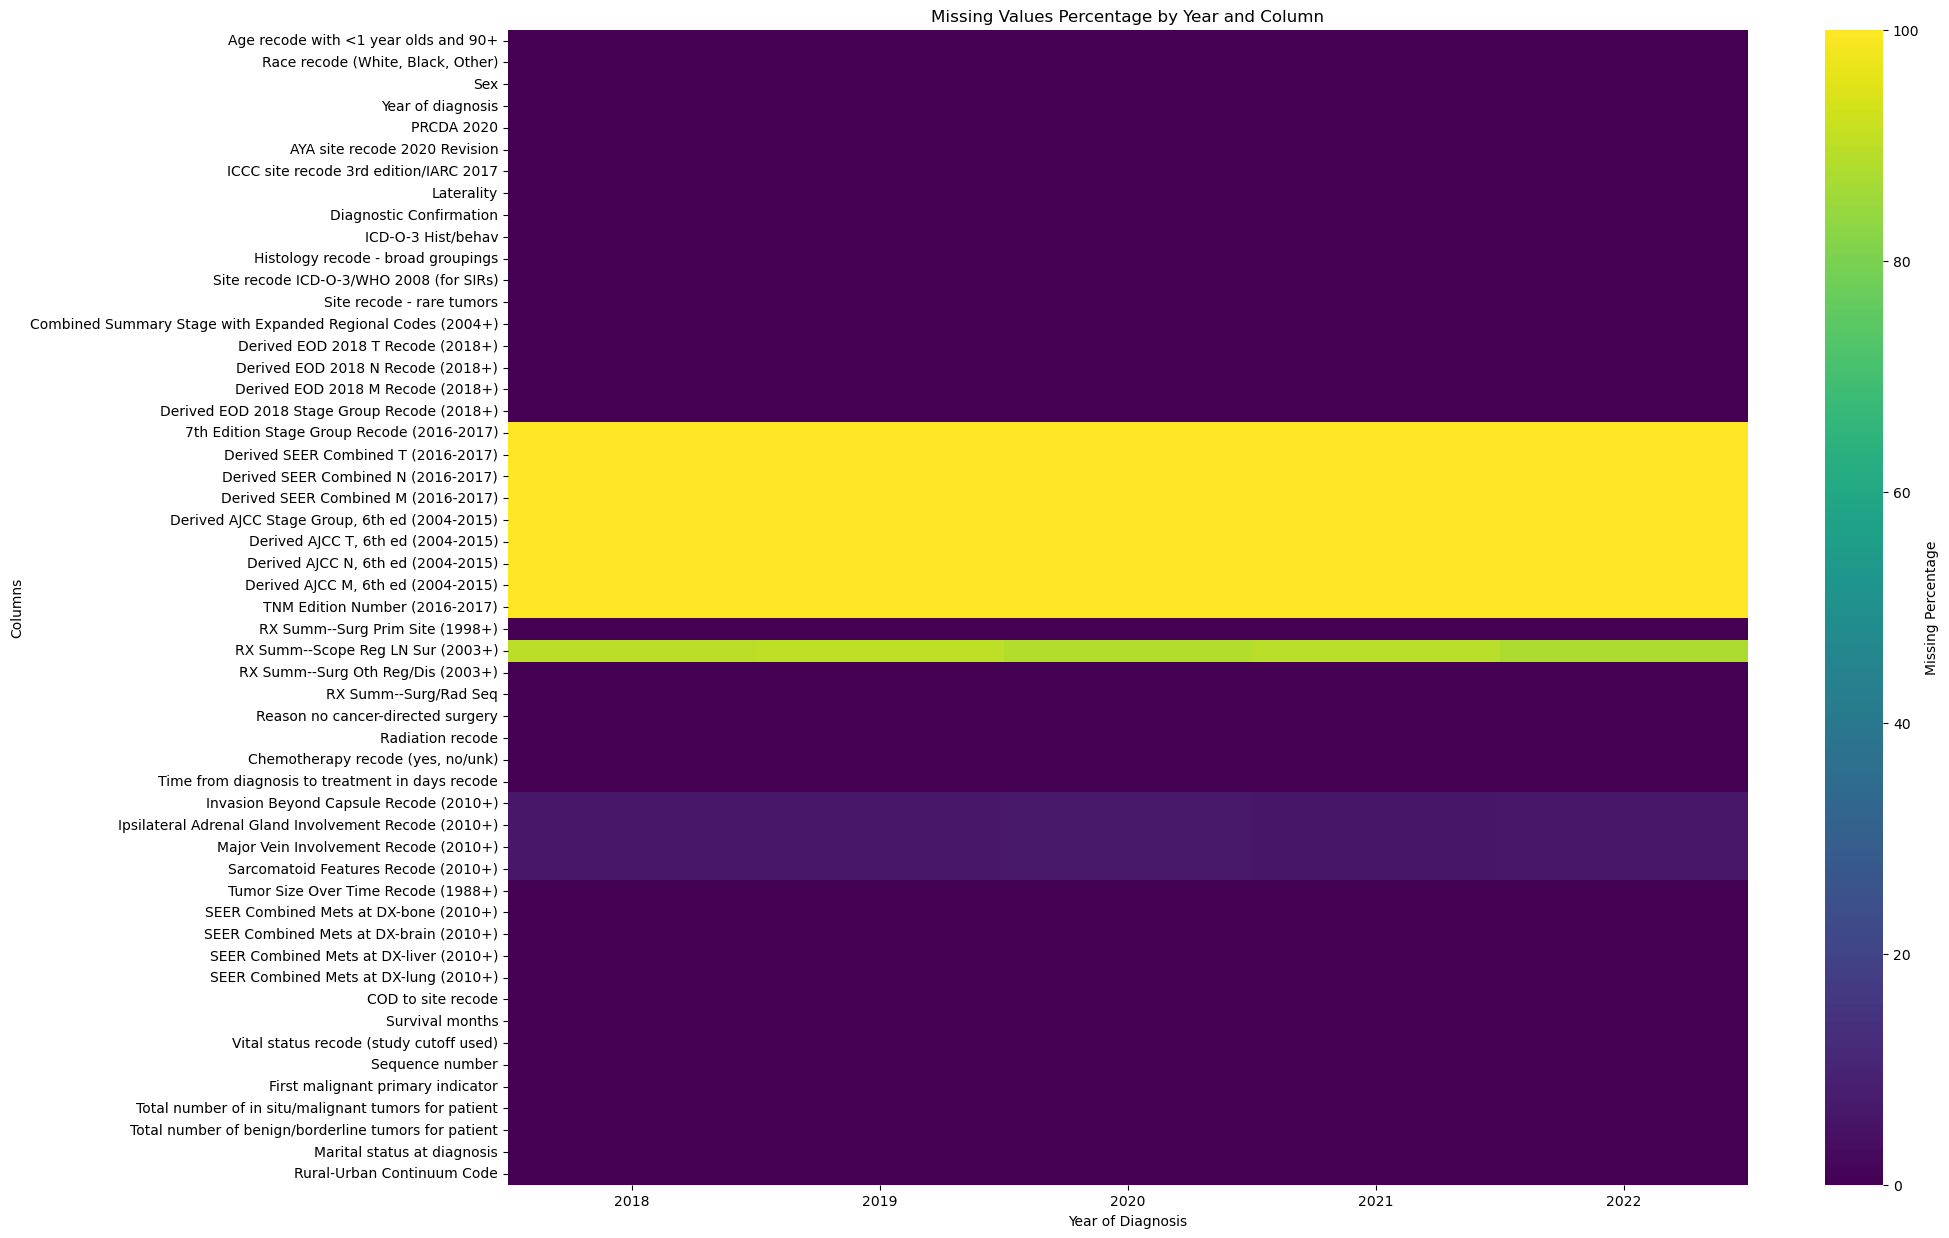

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Year of diagnosis' is treated as a year (assuming it's an integer or can be converted)
# If it's not in a suitable format, you might need to convert it first.
# For example, if it's a string, you might need:
# df['Year of diagnosis'] = pd.to_numeric(df['Year of diagnosis'], errors='coerce')

# Group by 'Year of diagnosis' and calculate the percentage of missing values per column per year
missing_by_year = df.groupby('Year of diagnosis').apply(lambda x: x.isnull().sum() / len(x) * 100).T

# Plot the heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(missing_by_year, cmap='viridis', cbar_kws={'label': 'Missing Percentage'})
plt.title('Missing Values Percentage by Year and Column')
plt.xlabel('Year of Diagnosis')
plt.ylabel('Columns')
plt.show()

In [41]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})

# Display columns with missing values
display(missing_info[missing_info['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False))

,Missing Values,Missing Percentage
7th Edition Stage Group Recode (2016-2017),25622,100.000000
Derived SEER Combined T (2016-2017),25622,100.000000
Derived SEER Combined N (2016-2017),25622,100.000000
Derived SEER Combined M (2016-2017),25622,100.000000
"Derived AJCC Stage Group, 6th ed (2004-2015)",25622,100.000000
"Derived AJCC T, 6th ed (2004-2015)",25622,100.000000
"Derived AJCC N, 6th ed (2004-2015)",25622,100.000000
"Derived AJCC M, 6th ed (2004-2015)",25622,100.000000
TNM Edition Number (2016-2017),25622,100.000000
RX Summ--Scope Reg LN Sur (2003+),22814,89.040668


In [42]:
# Identify columns with more than 40% missing values
columns_to_drop_high_missing = missing_info[missing_info['Missing Percentage'] > 40].index.tolist()

# Drop these columns from the DataFrame
df.drop(columns=columns_to_drop_high_missing, errors='ignore', inplace=True)

print("Shape of the DataFrame after removing columns with high missing percentage:")
display(df.shape)

Shape of the DataFrame after removing columns with high missing percentage:


(25622, 43)

In [43]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})

# Display columns with missing values
display(missing_info[missing_info['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False))

,Missing Values,Missing Percentage
Invasion Beyond Capsule Recode (2010+),1562,6.096323
Ipsilateral Adrenal Gland Involvement Recode (2010+),1562,6.096323
Major Vein Involvement Recode (2010+),1562,6.096323
Sarcomatoid Features Recode (2010+),1562,6.096323


In [44]:
df.dropna(inplace=True)

print("Shape of the DataFrame after dropping rows with missing values:")
display(df.shape)

Shape of the DataFrame after dropping rows with missing values:


(24060, 43)

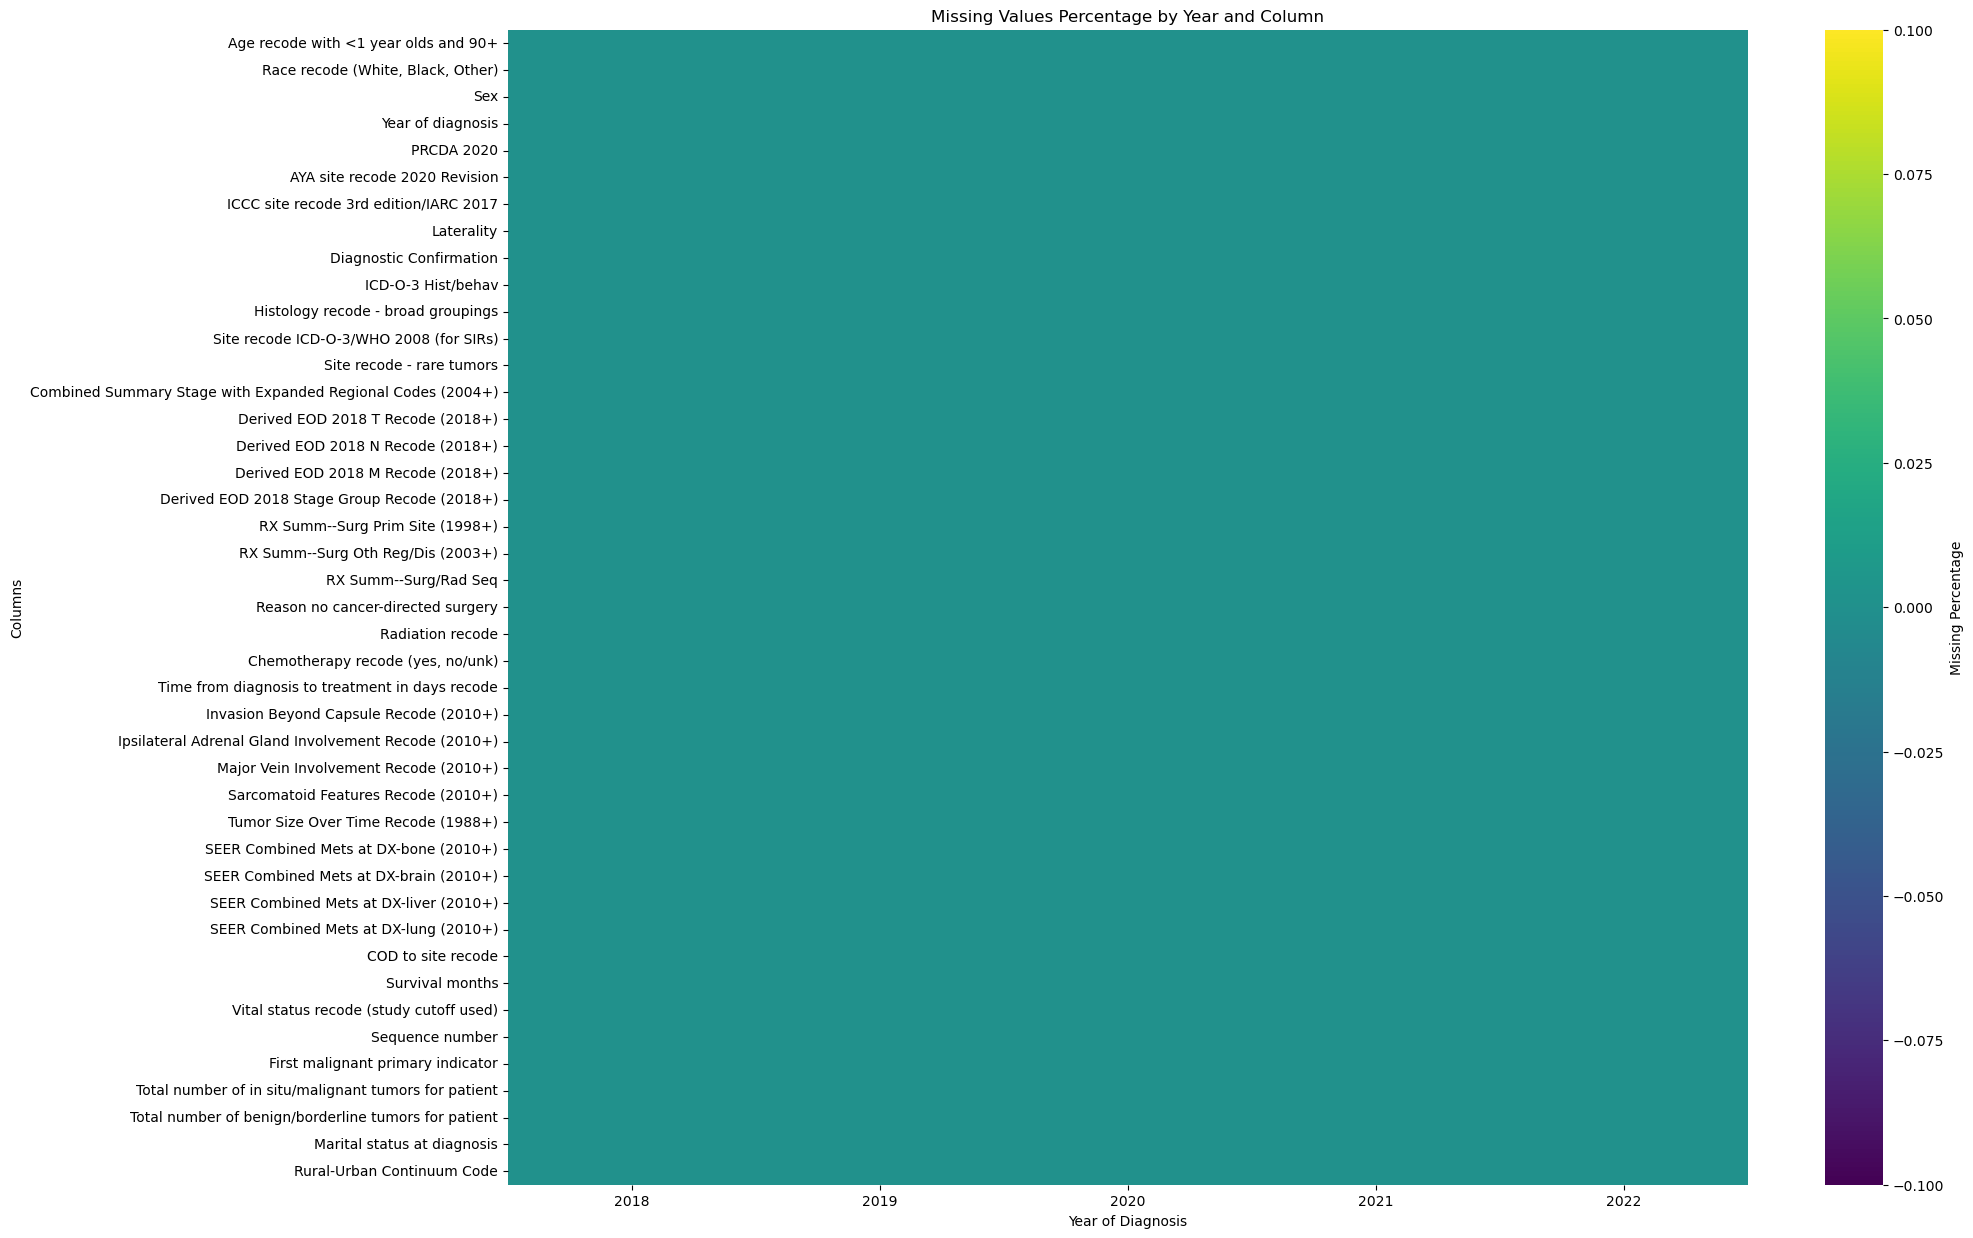

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Year of diagnosis' is treated as a year (assuming it's an integer or can be converted)
# If it's not in a suitable format, you might need to convert it first.
# For example, if it's a string, you might need:
# df['Year of diagnosis'] = pd.to_numeric(df['Year of diagnosis'], errors='coerce')

# Group by 'Year of diagnosis' and calculate the percentage of missing values per column per year
missing_by_year = df.groupby('Year of diagnosis').apply(lambda x: x.isnull().sum() / len(x) * 100).T

# Plot the heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(missing_by_year, cmap='viridis', cbar_kws={'label': 'Missing Percentage'})
plt.title('Missing Values Percentage by Year and Column')
plt.xlabel('Year of Diagnosis')
plt.ylabel('Columns')
plt.show()

In [46]:
df.columns

Index(['Age recode with <1 year olds and 90+',
       'Race recode (White, Black, Other)', 'Sex', 'Year of diagnosis',
       'PRCDA 2020', 'AYA site recode 2020 Revision',
       'ICCC site recode 3rd edition/IARC 2017', 'Laterality',
       'Diagnostic Confirmation', 'ICD-O-3 Hist/behav',
       'Histology recode - broad groupings',
       'Site recode ICD-O-3/WHO 2008 (for SIRs)', 'Site recode - rare tumors',
       'Combined Summary Stage with Expanded Regional Codes (2004+)',
       'Derived EOD 2018 T Recode (2018+)',
       'Derived EOD 2018 N Recode (2018+)',
       'Derived EOD 2018 M Recode (2018+)',
       'Derived EOD 2018 Stage Group Recode (2018+)',
       'RX Summ--Surg Prim Site (1998+)', 'RX Summ--Surg Oth Reg/Dis (2003+)',
       'RX Summ--Surg/Rad Seq', 'Reason no cancer-directed surgery',
       'Radiation recode', 'Chemotherapy recode (yes, no/unk)',
       'Time from diagnosis to treatment in days recode',
       'Invasion Beyond Capsule Recode (2010+)',
       'I

In [47]:
# Save the DataFrame to a CSV file
df.to_csv('RCC_cleaned_2018b.csv', index=False)

print("DataFrame saved to RCC_cleaned.csv")

DataFrame saved to RCC_cleaned.csv
